In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the automobile sales dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(URL)

# Ensure the date column is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

print("Data downloaded and read into a dataframe!")
print("Shape:", df.shape)
display(df.head())


Data downloaded and read into a dataframe!
Shape: (528, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,1980-02-29,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,1980-03-31,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,1980-04-30,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,1980-05-31,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [3]:
# Basic data inspection
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Columns:
['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']

Missing values:


,Missing Values
Date,0
Year,0
Month,0
Recession,0
Consumer_Confidence,0
Seasonality_Weight,0
Price,0
Advertising_Expenditure,0
Competition,0
GDP,0



Data types:


,Data Type
Date,datetime64[ns]
Year,int64
Month,object
Recession,int64
Consumer_Confidence,float64
Seasonality_Weight,float64
Price,float64
Advertising_Expenditure,int64
Competition,int64
GDP,float64


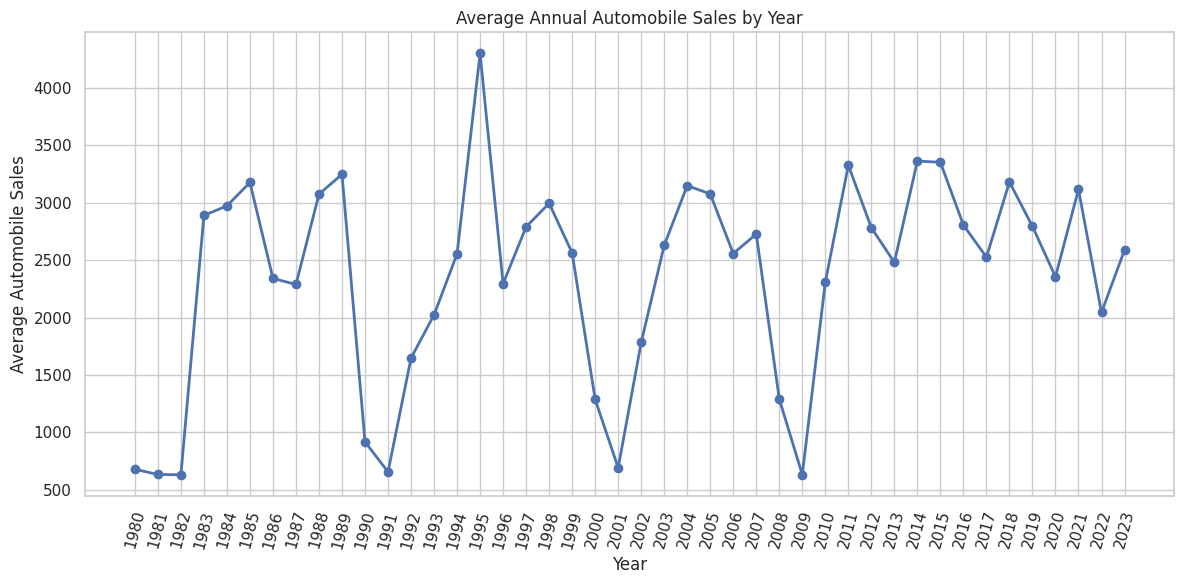

In [4]:
# Calculate average annual automobile sales
annual_sales = (
    df.groupby("Year")["Automobile_Sales"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(
    annual_sales["Year"],
    annual_sales["Automobile_Sales"],
    marker="o",
    linewidth=2
)
plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.title("Average Annual Automobile Sales by Year")
plt.xticks(annual_sales["Year"], rotation=75)
plt.tight_layout()
plt.savefig("Line_Plot_1.png", dpi=150, bbox_inches="tight")
plt.show()


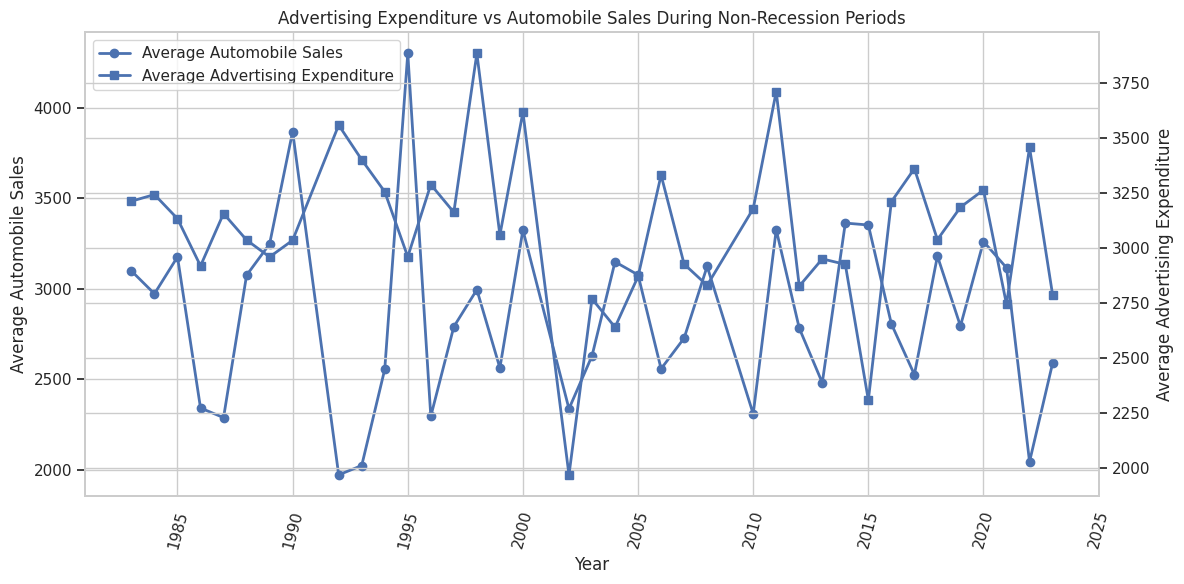

In [5]:
# Filter non-recession observations
non_recession_data = df[df["Recession"] == 0].copy()

# Aggregate by year
non_rec_trends = (
    non_recession_data.groupby("Year")[["Advertising_Expenditure", "Automobile_Sales"]]
    .mean()
    .reset_index()
)

# Plot both trends using two y-axes because the scales are different
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    non_rec_trends["Year"],
    non_rec_trends["Automobile_Sales"],
    marker="o",
    linewidth=2,
    label="Average Automobile Sales"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Automobile Sales")

ax2 = ax1.twinx()
ax2.plot(
    non_rec_trends["Year"],
    non_rec_trends["Advertising_Expenditure"],
    marker="s",
    linewidth=2,
    label="Average Advertising Expenditure"
)
ax2.set_ylabel("Average Advertising Expenditure")

ax1.set_title("Advertising Expenditure vs Automobile Sales During Non-Recession Periods")
ax1.tick_params(axis="x", rotation=75)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.savefig("Line_Plot_2.png", dpi=150, bbox_inches="tight")
plt.show()


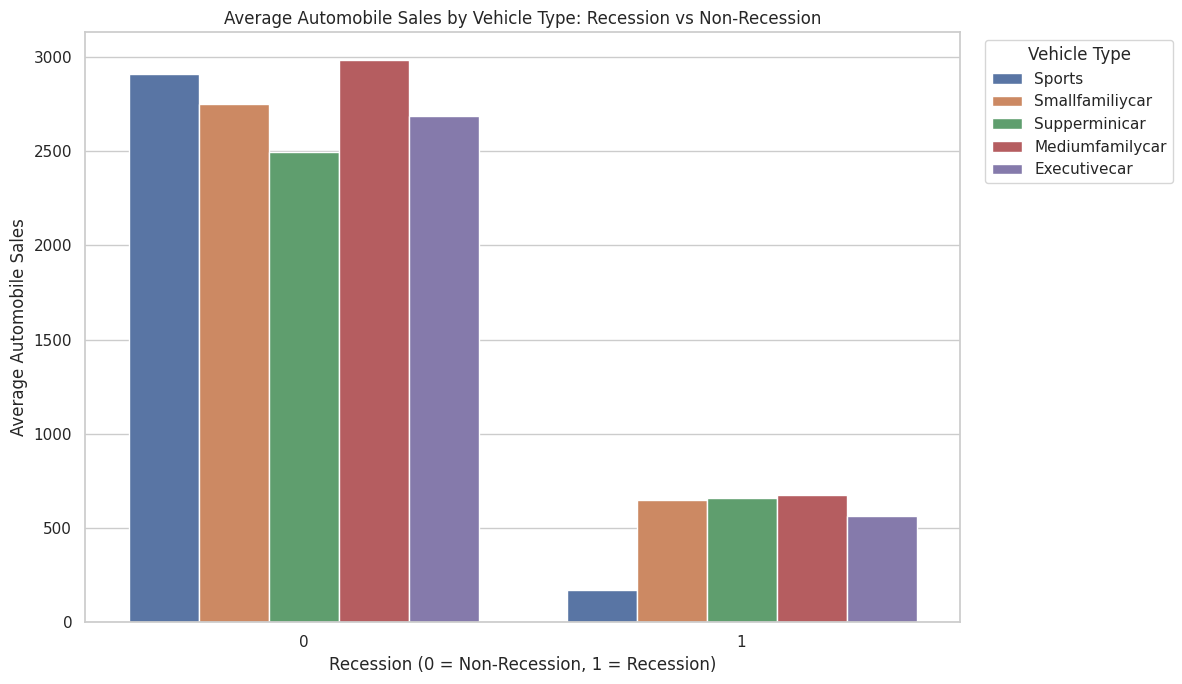

In [6]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=df,
    x="Recession",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    estimator="mean",
    errorbar=None
)

plt.xlabel("Recession (0 = Non-Recession, 1 = Recession)")
plt.ylabel("Average Automobile Sales")
plt.title("Average Automobile Sales by Vehicle Type: Recession vs Non-Recession")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Bar_Plot_1.png", dpi=150, bbox_inches="tight")
plt.show()


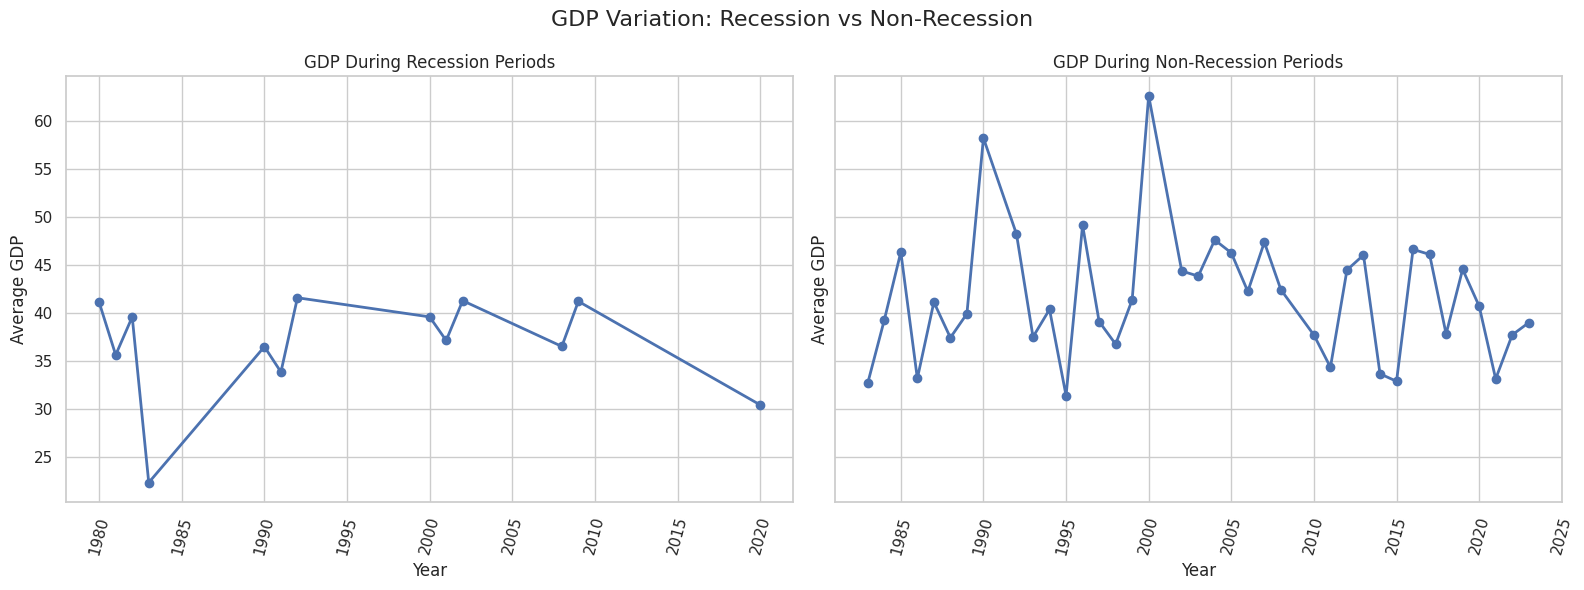

In [7]:
recession_data = df[df["Recession"] == 1].copy()
non_recession_data = df[df["Recession"] == 0].copy()

# Average GDP by year for each condition
rec_gdp = recession_data.groupby("Year")["GDP"].mean().reset_index()
non_rec_gdp = non_recession_data.groupby("Year")["GDP"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].plot(rec_gdp["Year"], rec_gdp["GDP"], marker="o", linewidth=2)
axes[0].set_title("GDP During Recession Periods")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")
axes[0].tick_params(axis="x", rotation=75)

axes[1].plot(non_rec_gdp["Year"], non_rec_gdp["GDP"], marker="o", linewidth=2)
axes[1].set_title("GDP During Non-Recession Periods")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average GDP")
axes[1].tick_params(axis="x", rotation=75)

fig.suptitle("GDP Variation: Recession vs Non-Recession", fontsize=16)
plt.tight_layout()
plt.savefig("Subplot_GDP.png", dpi=150, bbox_inches="tight")
plt.show()


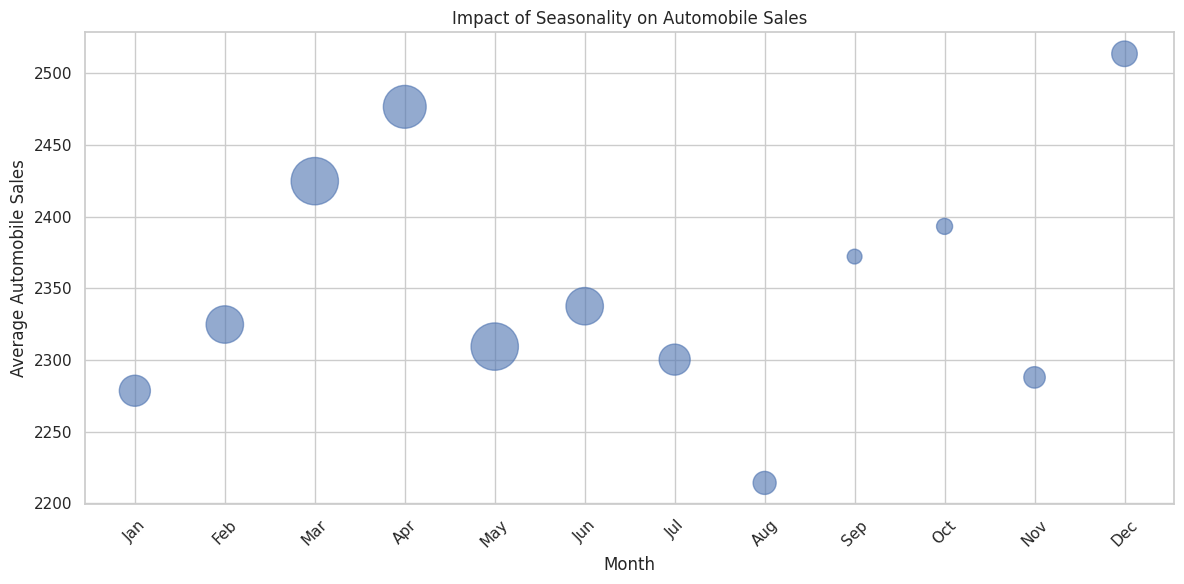

In [8]:
# Aggregate monthly sales and seasonality
seasonality_data = (
    df.groupby("Month")
      .agg(
          Automobile_Sales=("Automobile_Sales", "mean"),
          Seasonality_Weight=("Seasonality_Weight", "mean")
      )
      .reset_index()
)

# Keep calendar month order
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
seasonality_data["Month"] = pd.Categorical(
    seasonality_data["Month"],
    categories=month_order,
    ordered=True
)
seasonality_data = seasonality_data.sort_values("Month")

plt.figure(figsize=(12, 6))
plt.scatter(
    seasonality_data["Month"],
    seasonality_data["Automobile_Sales"],
    s=seasonality_data["Seasonality_Weight"] * 900 + 50,
    alpha=0.6
)

plt.xlabel("Month")
plt.ylabel("Average Automobile Sales")
plt.title("Impact of Seasonality on Automobile Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Bubble_Plot.png", dpi=150, bbox_inches="tight")
plt.show()


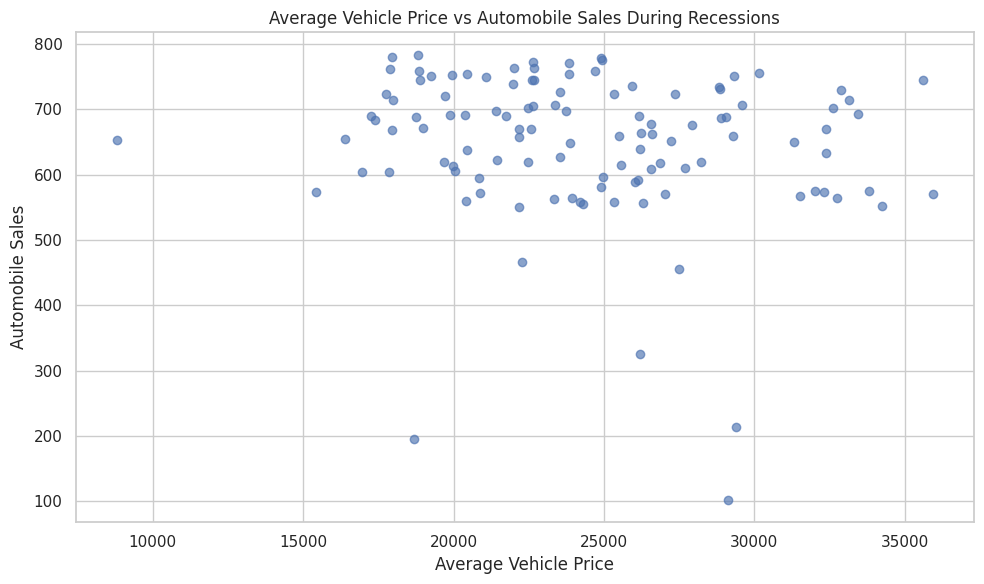

In [9]:
rec_price_sales = df[df["Recession"] == 1].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    rec_price_sales["Price"],
    rec_price_sales["Automobile_Sales"],
    alpha=0.65
)

plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.title("Average Vehicle Price vs Automobile Sales During Recessions")
plt.tight_layout()
plt.savefig("Scatter.png", dpi=150, bbox_inches="tight")
plt.show()


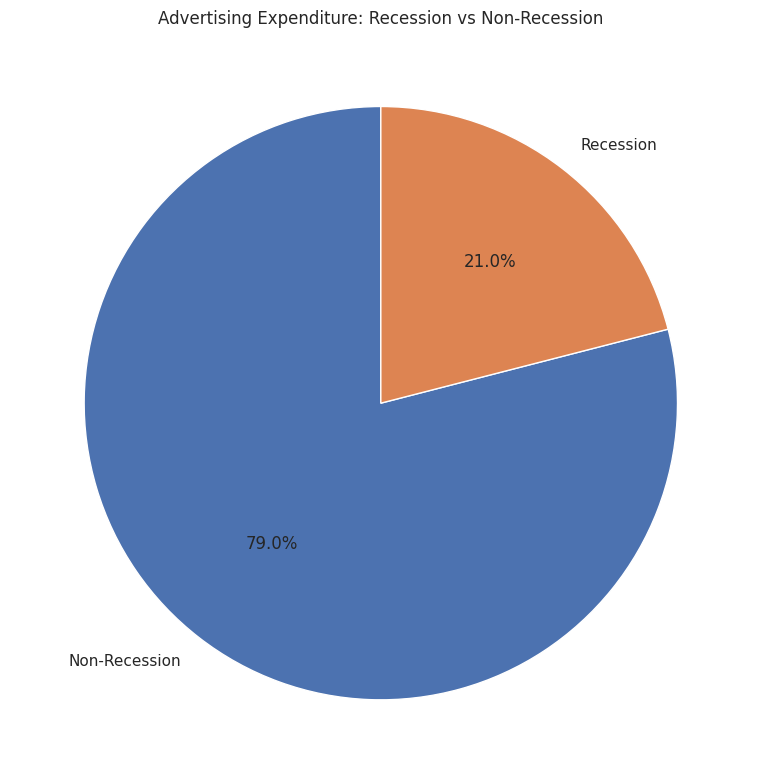

In [10]:
advertising_period = (
    df.groupby("Recession")["Advertising_Expenditure"]
      .sum()
)

labels = ["Non-Recession", "Recession"]

plt.figure(figsize=(8, 8))
plt.pie(
    advertising_period.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure: Recession vs Non-Recession")
plt.tight_layout()
plt.savefig("Pie_Chart_1.png", dpi=150, bbox_inches="tight")
plt.show()


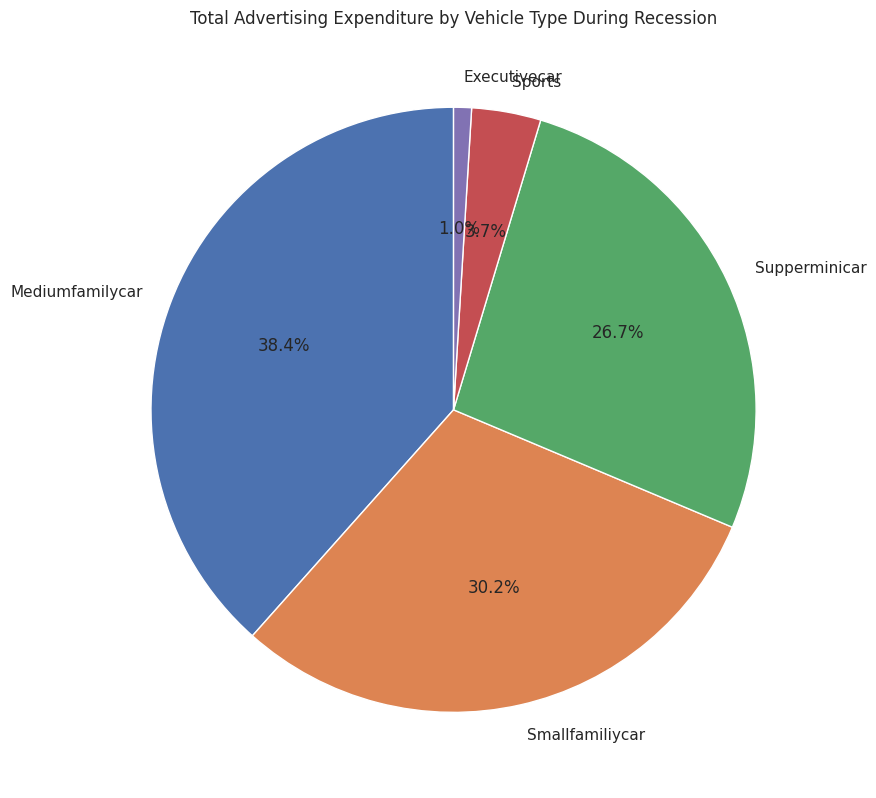

In [11]:
recession_advertising = (
    df[df["Recession"] == 1]
      .groupby("Vehicle_Type")["Advertising_Expenditure"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 9))
plt.pie(
    recession_advertising.values,
    labels=recession_advertising.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Total Advertising Expenditure by Vehicle Type During Recession")
plt.tight_layout()
plt.savefig("Pie_Chart_2.png", dpi=150, bbox_inches="tight")
plt.show()


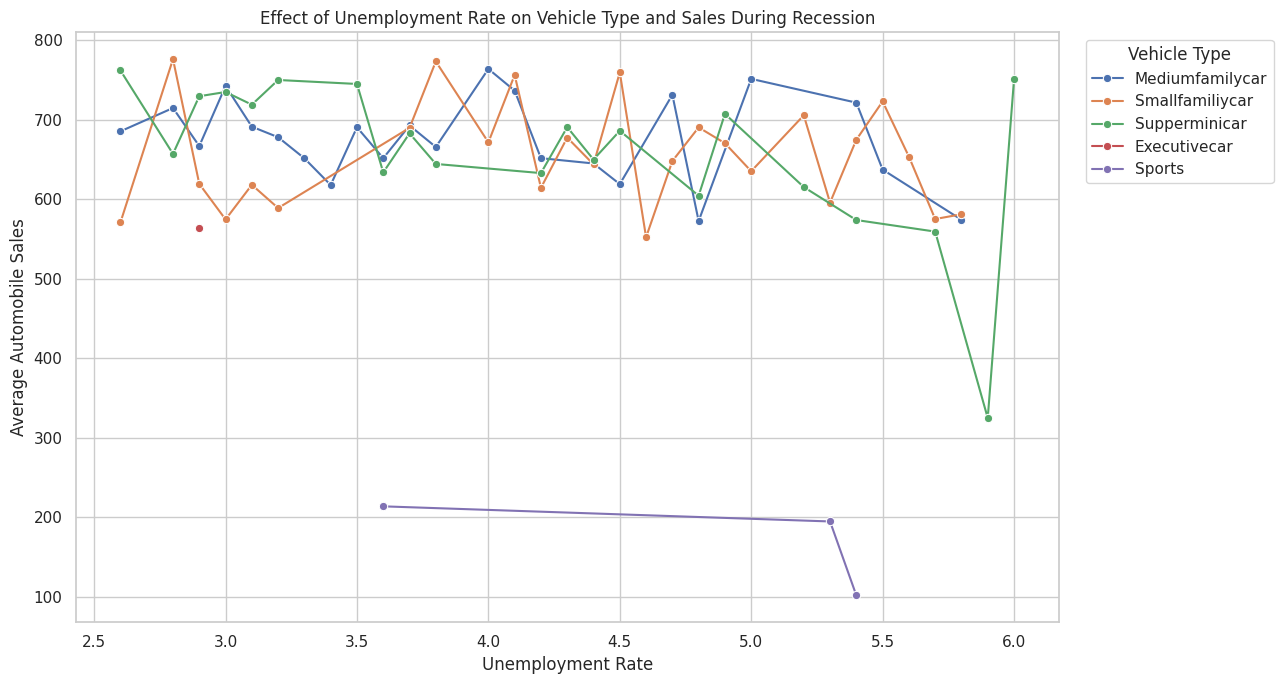

In [12]:
# Aggregate observations to make the line plot readable
unemployment_sales = (
    df[df["Recession"] == 1]
      .groupby(["Unemployment_Rate" if "Unemployment_Rate" in df.columns else "unemployment_rate",
                "Vehicle_Type"])["Automobile_Sales"]
      .mean()
      .reset_index()
)

unemployment_col = (
    "Unemployment_Rate"
    if "Unemployment_Rate" in unemployment_sales.columns
    else "unemployment_rate"
)

unemployment_sales = unemployment_sales.sort_values(unemployment_col)

plt.figure(figsize=(13, 7))
sns.lineplot(
    data=unemployment_sales,
    x=unemployment_col,
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o"
)

plt.xlabel("Unemployment Rate")
plt.ylabel("Average Automobile Sales")
plt.title("Effect of Unemployment Rate on Vehicle Type and Sales During Recession")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("Line_Plot_3.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
required_columns = [
    "Date", "Year", "Month", "Recession", "Automobile_Sales",
    "GDP", "Seasonality_Weight", "Price",
    "Advertising_Expenditure", "Vehicle_Type"
]

# The course dataset may use either spelling/capitalization for unemployment rate.
unemployment_present = (
    "Unemployment_Rate" in df.columns or
    "unemployment_rate" in df.columns
)

missing = [col for col in required_columns if col not in df.columns]

print("Required columns present:", len(missing) == 0)
print("Unemployment-rate column present:", unemployment_present)

if missing:
    print("Missing columns:", missing)
else:
    print("All core columns required by Tasks 1.1–1.9 are available.")

print("\nNotebook completed: Tasks 1.1 through 1.9.")


Required columns present: True
Unemployment-rate column present: True
All core columns required by Tasks 1.1–1.9 are available.

Notebook completed: Tasks 1.1 through 1.9.
